#  DSC680-T302 Applied Data Science #

## Week 8 -  Project 2 - Milestone 2 supporting ##

### Saravanan Janarthanan ###
-----

### Automated Scene Classification Using Deep Learning ###
**Enhancing image categorization accuracy and efficiency across diverse applications through AI-driven solutions.**

#### Summary ####

This project focuses on developing an advanced deep learning-based system for automatic scene classification from images. Scene classification is critical in various domains including autonomous navigation, digital media management, and remote sensing, where rapid and accurate categorization of large volumes of image data is essential. The proposed solution aims to eliminate the need for manual tagging—an often inconsistent and time-intensive process—by leveraging deep learning techniques to accurately and efficiently classify natural scenes into predefined categories. This system will enhance scalability, reduce human error, and support real-time decision-making in data-driven environments.

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation, MaxPooling2D
from tensorflow.keras import Sequential
import os
from tqdm import tqdm

In [2]:
print(tf.__version__)

2.19.0



-----

### Dataset ###


The images are organized in folders corresponding to each class label. Each folder name, such as buildings, forest, glacier, mountain, sea, and street represents a category, and the dataset is split into separate training and testing directories, maintaining this structure. 


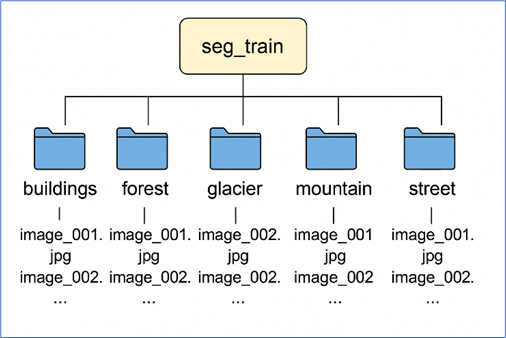



In [3]:
# Load the training and test image root folder,  under each the class folders are loacted 
train_img_fldr = './Data/seg_train/seg_train'
test_img_dir = './Data/seg_test/seg_test'

In [4]:
# Load train data
filepaths_img_train_data, img_label_train_data = [], []

for fldr in os.listdir(train_img_fldr):
    fldrpath = os.path.join(train_img_fldr, fldr)
    for file in tqdm(os.listdir(fldrpath)):
        filepaths_img_train_data.append(os.path.join(fldrpath, file))
        img_label_train_data.append(fldr)

100%|██████████████████████████████████████████████████████████████████████████████████████| 2382/2382 [00:00<?, ?it/s]


In [5]:
# Load test data
filepaths_img_test_data, img_label_test_data = [], []

for fldr in os.listdir(test_img_dir):
    fldrpath = os.path.join(test_img_dir, fldr)
    for file in tqdm(os.listdir(fldrpath)):
        filepaths_img_test_data.append(os.path.join(fldrpath, file))
        img_label_test_data.append(fldr)

100%|████████████████████████████████████████████████████████████████████████████████████████| 501/501 [00:00<?, ?it/s]


In [6]:
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

train_counts = Counter(img_label_train_data)
test_counts = Counter(img_label_test_data)

# Create a DataFrame to align the counts
df_viz = pd.DataFrame([train_counts, test_counts]).T.fillna(0)
df_viz.columns = ['Train_data', 'Test_data']
df_viz = df_viz.astype(int)

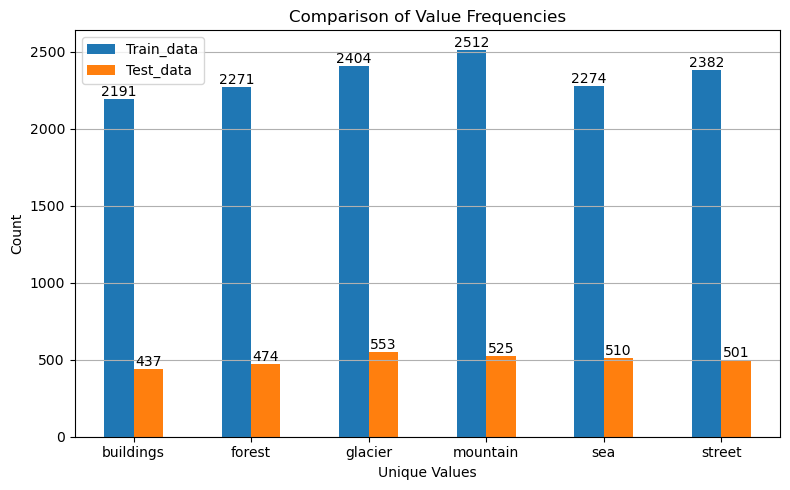

In [7]:
ax = df_viz.plot(kind='bar', figsize=(8, 5), rot=0) 
plt.title('Comparison of Value Frequencies')
plt.xlabel('Unique Values')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend()

# Add data labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

**Training Data:**<br>
- Classes (buildings, forest, glacier, mountain, sea, street) have counts ranging from 2191 to 2512.<br>
- The highest count is for mountain (2512) and the lowest is buildings (2191).<br>

**Test Data:**<br>
- Counts range from 437 to 553.<br>
- Again, glacier has slightly higher test samples (553), and buildings has the least (437).<br>

**Observation:**<br>
- The data is reasonably balanced.<br>
- The difference between classes is around 300 samples (at most), which is not very severe.<br>
- Both training and testing sets maintain this balance fairly consistently.<br>


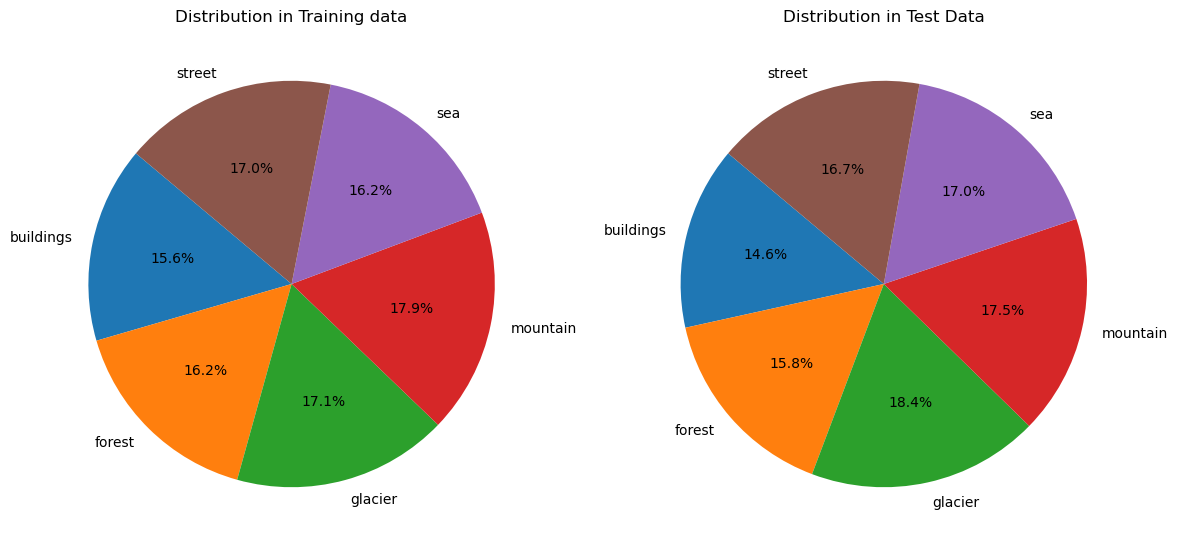

In [8]:
# Set up the figure
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot Pie Chart for List 1
axes[0].pie(train_counts.values(), labels=train_counts.keys(), autopct='%1.1f%%', startangle=140)
axes[0].set_title('Distribution in Training data')

# Plot Pie Chart for List 2
axes[1].pie(test_counts.values(), labels=test_counts.keys(), autopct='%1.1f%%', startangle=140)
axes[1].set_title('Distribution in Test Data')

plt.tight_layout()
plt.show()

**Training Set:**<br>
- Each class is roughly around 15-18%.<br>
- Mountain (17.9%) and Glacier (17.1%) are a bit dominant.<br>
- Buildings (15.6%) is slightly underrepresented.<br>

**Test Set:**<br>
- Very similar distribution.<br>
- Glacier is slightly higher (18.4%), Buildings again lower (14.6%).<br>

**Observation:**<br>
- Good stratification between training and testing splits.<br>
- No class severely overpowers others (>20%), and no class falls too low (<10%).<br>


-----
-----

### Data Preprocessing ###

All images are resized to a uniform shape (150x150 for CNN and 224 X 224 for Mobilenet and Resnet) to match the model input requirements. Pixel values are normalized to improve convergence during training. The images are loaded using TensorFlow’s ImageDataGenerator, which also applies on-the-fly augmentation during training to improve generalization.<br>

- Image resizing (150×150 for CNN, 224×224 for transfer learning models)
- Pixel normalization to [0,1]
- Apply data augmentation (random rotations, flips, brightness adjustments) using ImageDataGenerator to enhance model generalization.




In [9]:
# 1. Data Preprocessing using ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,                   # Normalize the pixel values fro [0,255] to [0,1] , helps to execute faster
    rotation_range=20,                # Randomly rortate the images to help model to understand images on any orienttation
    width_shift_range=0.2,            # Randomly shifts image horizontally by 20%, to reconize partial images
    height_shift_range=0.2,           # Randomly shifts image vertically by 20%, to reconize partial images
    zoom_range=0.2,                   # Randomly zooms images in or out by up to 20%, to simulate scale variation.
    horizontal_flip=True              # Randomly flips images left-to-right, Useful understand natuarla scence image patterns
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [10]:
# Use ImageDataGenerator to load and preprocess image data from a directory structure. 
# Returned generator can be used to feed batches of image data into a model during training or evaluation.
def generate_image_data(img_datagen, fldr_path, img_size):
    img_data = img_datagen.flow_from_directory(
        fldr_path,
        target_size=img_size,
        batch_size=32,
        class_mode='categorical'
    )
    
    return img_data

In [69]:
# Utility function to plot training accuracy and loss using the model training output (history)
def plot_training_history(model_type, history):
    hist_df = pd.DataFrame(history.history)

    print("Accuracy and Loss in ", model_type, " Model")
    # Plot Accuracy
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(hist_df['accuracy'], label='Train Accuracy')
    plt.plot(hist_df['val_accuracy'], label='Val Accuracy')
    plt.title(model_type + ' Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(hist_df['loss'], label='Train Loss')
    plt.plot(hist_df['val_loss'], label='Val Loss')
    plt.title(model_type+ ' Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [33]:
# Utility fucntion to get true labels and predictions
def predict_model(model, test_data, max_batches=None):
    y_true = []
    y_pred = []

    for i, (images, labels) in enumerate(test_data):
        if max_batches is not None and i >= max_batches:
            break
            
        # Get true labels from one-hot encoding
        y_true.extend(np.argmax(labels, axis=1))

        # Get model predictions
        preds = model.predict(images,  verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))

    return np.array(y_true), np.array(y_pred)

In [13]:
# Utility fucntion to get generate Classificsation report that can be used to print confusion matrix
from sklearn.metrics import classification_report

def print_classification_report(model_nm, y_true, y_pred, class_names):
    print(model_nm + " Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    

----
----

### Model Training ###

----

#### CNN Model ####

Custom CNN model Architecture as listed below is used to train the image data

**Architecture**<br>
Architecture Overview:
- Input Layer: Accepts images typically resized (e.g., 150x150 or 224x224).
- Convolutional Layers: Multiple stacked layers with filters (kernels) that detect spatial features like edges, textures, and patterns.
- Often followed by activation functions (ReLU) to introduce non-linearity.
- Pooling Layers: Typically MaxPooling2D to reduce dimensionality and computational load while preserving key features.
- Flatten Layer: Converts 2D feature maps into a 1D vector before passing to dense layers.
- Dense (Fully Connected) Layers: Learn complex patterns and combine features to make final predictions.
- Output Layer: Uses softmax activation for multi-class classification (one class per scene type).


Input Image (150x150x3)   (Input Shape w 150, h 150, and 3 color channels (RGB).<br>
    ↓<br>
Conv2D(32) + ReLU              (with ReLU activation and same padding)<br>
    ↓<br>
MaxPooling2D                      (reduces spatial dimensions by a factor of 2.)<br>
    ↓<br>
Conv2D(64) + ReLU<br>
    ↓<br>
MaxPooling2D<br>
    ↓<br>
Conv2D(128) + ReLU<br>
    ↓<br>
MaxPooling2D<br>
    ↓<br>
Conv2D(256) + ReLU<br>
    ↓<br>
MaxPooling2D<br>
    ↓<br>
Conv2D(512) + ReLU<br>
    ↓<br>
MaxPooling2D<br>
    ↓<br>
Flatten  (Convert the feature maps into a 1D vector fed into fully connected  layers).<br>
    ↓<br>
Dense(512) + ReLU  (To Combine high-level features for classification.)<br>
    ↓<br>
Dense(num_classes) + Softmax  <br>
(num_classes = 6,  and softmax is used as classification is non-binary)


In [14]:
train_data_cnn = generate_image_data(train_datagen, train_img_fldr, (150 , 150))

Found 14034 images belonging to 6 classes.


In [15]:
test_data_cnn = generate_image_data(test_datagen, test_img_dir, (150 , 150))

Found 3000 images belonging to 6 classes.


In [16]:
# Build CNN Model

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(150, 150, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dense(train_data_cnn.num_classes, activation='softmax')  # Automatically adapts to number of folders
])


C:\Users\poorn\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# Compile the model
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])




In [18]:
# Train the model
history_cnn = model.fit(
    train_data_cnn,
    validation_data=test_data_cnn,
    epochs=10
)

C:\Users\poorn\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 134s 302ms/step - accuracy: 0.4547 - loss: 1.2966 - val_accuracy: 0.6127 - val_loss: 0.9454
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 127s 289ms/step - accuracy: 0.6405 - loss: 0.9088 - val_accuracy: 0.7297 - val_loss: 0.7128
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 127s 290ms/step - accuracy: 0.7259 - loss: 0.7326 - val_accuracy: 0.7970 - val_loss: 0.5692
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 127s 289ms/step - accuracy: 0.7624 - loss: 0.6376 - val_accuracy: 0.8093 - val_loss: 0.5417
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 128s 291ms/step - accuracy: 0.7888 - loss: 0.5927 - val_accuracy: 0.8337 - val_loss: 0.4689
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 128s 290ms/step - accuracy: 0.8054 - loss: 0.5533 - val_accuracy: 0.8220 - val_loss: 0.4835
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 127s 288ms/step - accuracy: 0.8152 - loss: 0.5290 - val_accuracy: 0.8483 - val_loss: 0.4275
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 126s 288ms/step - accuracy: 0.8153 -

Accuracy and Loss in  CNN  Model


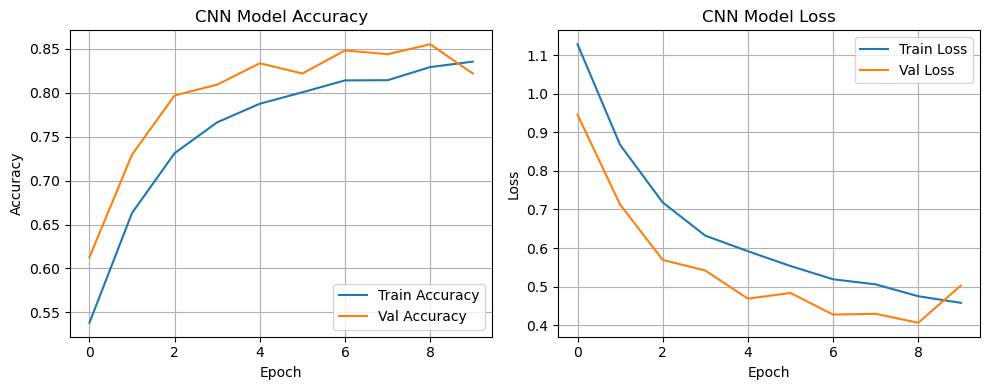

In [70]:
# Plot the accuracy and loss for CNN Model
plot_training_history("CNN", history_cnn)

#### CNN Model assesment ####

**CNN Model Accuracy** <br>
- Both training and validation accuracy increase steadily across epochs.
- Validation Accuracy rises quickly and peaks around epoch 7–8, slightly dipping at the end.
- Training Accuracy shows a smooth, gradual increase without plateauing.<br>
The model is learning well, and the close tracking between training and validation accuracy indicates good generalization with minimal overfitting.

**CNN Model Loss**<br>
- Both training and validation loss decrease steadily.
- Validation Loss hits its lowest around epoch 8, but then slightly increases.
- Training Loss continues to decrease gradually.<br>
 A small uptick in validation loss after epoch 8 while training loss continues to drop may be an early sign of overfitting

-----

#### MobileNet Model ####

The MobileNetV2 model used  is a pretrained convolutional neural network designed for efficient image classification, particularly on resource-constrained devices.

**Architecture Overview:**<br>
- Base Model: MobileNetV2 is loaded with pretrained weights (typically from ImageNet) and used as a feature extractor.<br>
- Inverted Residual Blocks: Core building blocks that reduce computational cost while maintaining performance, using depthwise separable convolutions.<br>
- Global Average Pooling: Replaces fully connected layers to reduce overfitting and model size.<br>
- Custom Classification Head: A small, task-specific fully connected layer stack (typically Dense layers and dropout) added on top of the base for scene classification.<br>

In [19]:
train_data_monresnet = generate_image_data(train_datagen, train_img_fldr, (224 , 224))

Found 14034 images belonging to 6 classes.


In [20]:
test_data_monresnet = generate_image_data(test_datagen, test_img_dir, (224 , 224))

Found 3000 images belonging to 6 classes.


In [22]:
class_names = list(train_data_cnn.class_indices.keys()) 

In [23]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load the base model with pretrained weights
base_model_mobnet = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,  # exclude default classification head
                         weights='imagenet')

# Freeze the base model layers
base_model_mobnet.trainable = False

# Add custom classification layers
x = base_model_mobnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(len(class_names), activation='softmax')(x)

# Final model
model_mobnet = Model(inputs=base_model_mobnet.input, outputs=predictions)

# Compile the model
model_mobnet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train
history_mobnet = model_mobnet.fit(train_data_monresnet, validation_data=test_data_monresnet, epochs=4)


Epoch 1/4
439/439 ━━━━━━━━━━━━━━━━━━━━ 260s 584ms/step - accuracy: 0.7909 - loss: 0.5562 - val_accuracy: 0.9000 - val_loss: 0.2555
Epoch 2/4
439/439 ━━━━━━━━━━━━━━━━━━━━ 259s 590ms/step - accuracy: 0.8789 - loss: 0.3277 - val_accuracy: 0.9037 - val_loss: 0.2560
Epoch 3/4
439/439 ━━━━━━━━━━━━━━━━━━━━ 254s 578ms/step - accuracy: 0.8926 - loss: 0.2896 - val_accuracy: 0.9037 - val_loss: 0.2464
Epoch 4/4
439/439 ━━━━━━━━━━━━━━━━━━━━ 261s 595ms/step - accuracy: 0.8942 - loss: 0.2838 - val_accuracy: 0.9047 - val_loss: 0.2428


Accuracy and Loss in  Mobile Net   Model


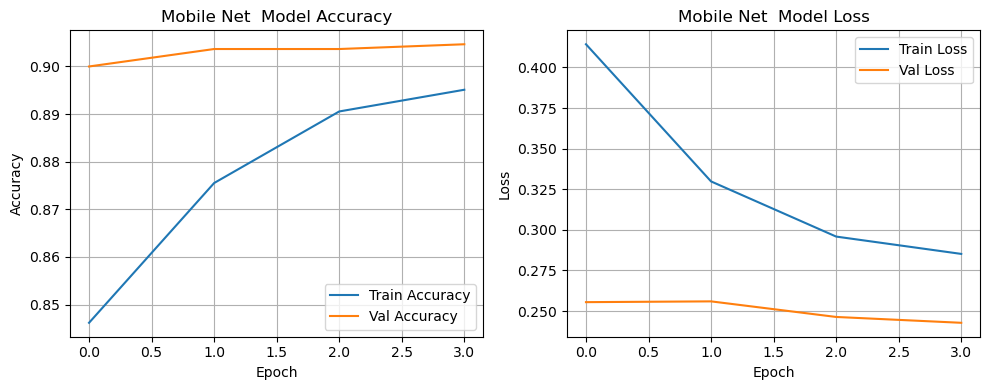

In [71]:
# Plot the accuracy and loss for MobileNet Model
plot_training_history("Mobile Net ", history_mobnet)

#### MobileNet Model assesment ####

**MobileNet Model Accuracy** <br>
- Validation Accuracy starts high at around 0.90 and remains very stable, showing only slight improvement.
- Training Accuracy steadily increases, approaching validation accuracy by epoch 3.<br>
The model begins with strong generalization, likely due to transfer learning from pretrained weights. It continues to improve in training with no signs of divergence.

**MobileNet Model Loss**<br>
- Training Loss decreases consistently across all epochs, indicating effective learning.
- Validation Loss is very low from the start and decreases slightly over time.<br>
 Very low and stable validation loss suggests the model is not overfitting and maintains strong generalization.

-----

#### ResNet50 Model ####

The ResNet50 model is a 50-layer deep convolutional neural network based on the ResNet (Residual Network) architecture, which is known for its ability to train very deep networks using skip (residual) connections.

**Architecture Overview:**<br>
- Pretrained Backbone: Typically initialized with ImageNet weights and adapted for the scene classification task.<br>
- Residual Connections: Allow the model to bypass layers, solving the vanishing gradient problem and enabling deeper architectures.<br>
- Deep Layer Stack: Consists of convolutional layers, batch normalization, and ReLU activations arranged in blocks.<br>
- Custom Head: A classification layer stack (usually dense layers) is added on top for domain-specific predictions.<br>

In [26]:
from tensorflow.keras.applications import ResNet50
base_model_rsnet = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')


In [25]:

# Freeze the base model layers
base_model_rsnet.trainable = False

# Add custom classification layers
x = base_model_rsnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(len(class_names), activation='softmax')(x)

# Final model
model_rsnet = Model(inputs=base_model_rsnet.input, outputs=predictions)

# Compile the model
model_rsnet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train
history_rsnet = model_rsnet.fit(train_data_monresnet, validation_data=test_data_monresnet, epochs=5)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 480s 1s/step - accuracy: 0.3028 - loss: 1.6143 - val_accuracy: 0.4363 - val_loss: 1.2740
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 478s 1s/step - accuracy: 0.4352 - loss: 1.3243 - val_accuracy: 0.4917 - val_loss: 1.1825
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 532s 1s/step - accuracy: 0.4712 - loss: 1.2524 - val_accuracy: 0.5890 - val_loss: 1.0703
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 485s 1s/step - accuracy: 0.5064 - loss: 1.2066 - val_accuracy: 0.5793 - val_loss: 1.0551
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 482s 1s/step - accuracy: 0.5268 - loss: 1.1529 - val_accuracy: 0.5643 - val_loss: 1.0340


Accuracy and Loss in  ResNet50  Model


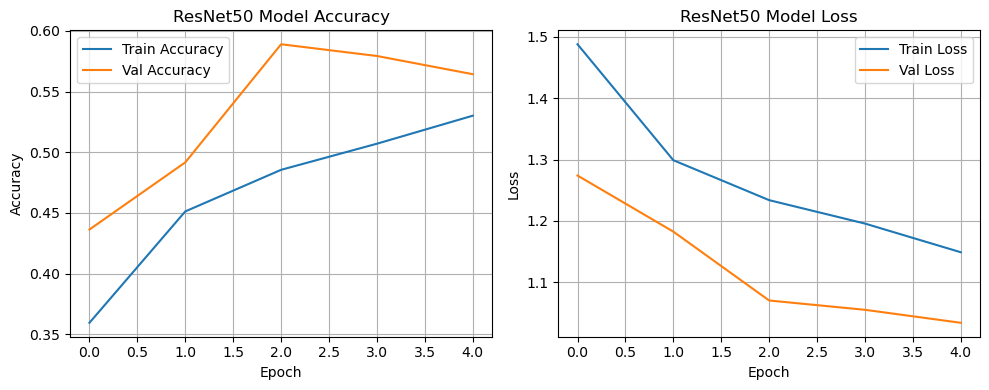

In [72]:
plot_training_history("ResNet50", history_rsnet)

#### ResNet50 Model assesment ####

**ResNet50 Model Accuracy** <br>
- Training Accuracy starts low (~0.36) and increases gradually to just above 0.52 by epoch 4.
- Validation Accuracy shows a sharp rise until epoch 2 (~0.59), followed by a slight decline through epochs 3–4.<br>
While the model is learning, the improvement is slow and limited. The peak in validation accuracy followed by a decline suggests potential overfitting or training instability.

**ResNet50 Model Loss**<br>
- Training Loss decreases consistently, indicating some improvement in model fitting.
- Validation Loss drops at first but levels off, showing only slight gains after epoch 2.<br>
 While the model is reducing error, the plateau in validation loss implies it's not generalizing well, despite continued training improvements.

----

-----
### Evaluate Models ###

The performance of each trained deep learning model is assessed using a designated evaluation dataset. This dataset is organized into folders by class name, with corresponding images placed under each. For every image, the model’s predicted label is compared with the actual class (inferred from the folder name). These predictions are then aggregated to compute key evaluation metrics:

- **Precision**: Measures how many predicted positives are actually correct.
- **Recall**   : Measures how many actual positives are correctly predicted.
- **F1 Score** : The harmonic mean of precision and recall, giving a balanced measure.

**Confusion Matrix**<br>
A confusion matrix is generated for each model, offering a visual summary of how well the model distinguishes between different classes by showing the distribution of true versus predicted labels.

In [28]:
eval_img_dir = './Data/seg_validation'

In [29]:

eval_data_cnn = generate_image_data(test_datagen, eval_img_dir, (150 , 150))

eval_data_mobes = generate_image_data(test_datagen, eval_img_dir, (224 , 224))



Found 1261 images belonging to 6 classes.
Found 1261 images belonging to 6 classes.


In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Helper function for full evaluation
def evaluate_model(model_name, model, test_data, class_names, max_batches=None):
    y_true, y_pred = predict_model(model, test_data, max_batches=max_batches)
    
    print(f"\n=== {model_name} Evaluation ===")
    prec_scr = precision_score(y_true, y_pred, average='weighted')
    print("Precision:", prec_scr)
    recl_scr = recall_score(y_true, y_pred, average='weighted')
    print("Recall:", recl_scr)
    f1_scr = f1_score(y_true, y_pred, average='weighted')
    print("F1 Score:", f1_scr)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(xticks_rotation=45)
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    return prec_scr, recl_scr, f1_scr



=== CNN Evaluation ===
Precision: 0.8437091549739564
Recall: 0.8364958886780519
F1 Score: 0.8336694126261288


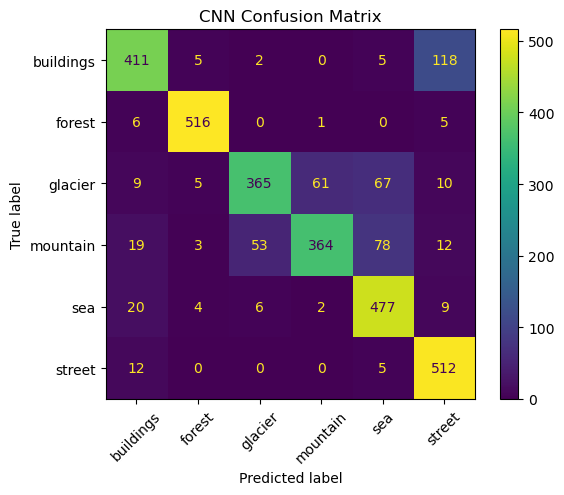


=== MobileNetV2 Evaluation ===
Precision: 0.898642881791233
Recall: 0.898798228969007
F1 Score: 0.8981715219929248


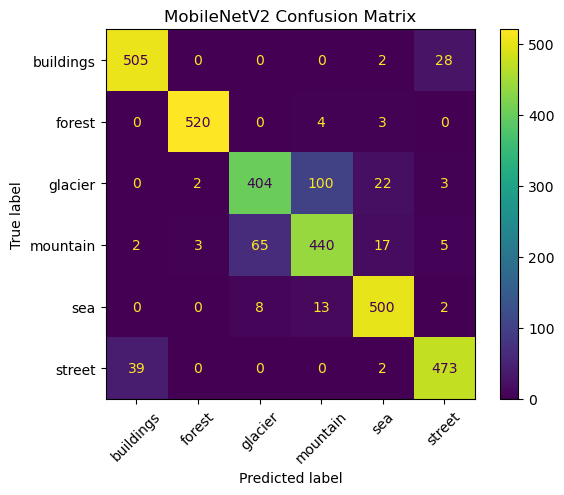


=== ResNet50 Evaluation ===
Precision: 0.5965359164793989
Recall: 0.5736557429207764
F1 Score: 0.550542783869792


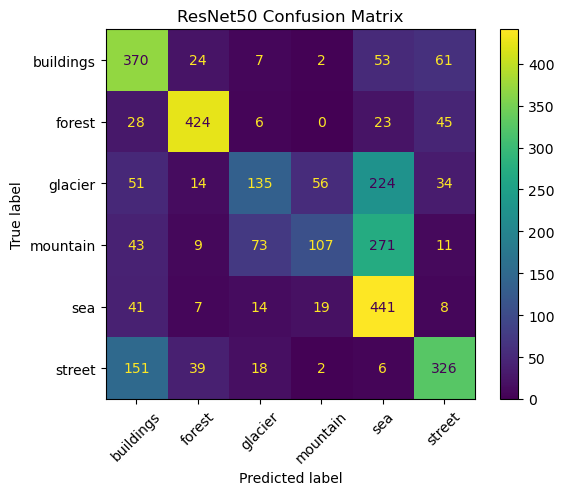

In [61]:

# Evlauate  CNN
cnn_pres_scr , cnn_recl_scr, cnn_f1_scr = evaluate_model("CNN", model, eval_data_cnn, class_names, max_batches=100)

# Evlauate MobileNetV2
mobnet_pres_scr , mobnet_recl_scr, mobnet_f1_scr = evaluate_model("MobileNetV2", model_mobnet, eval_data_mobes, class_names, max_batches=100)

# Evlauate ResNet50
resnet_pres_scr , resnet_recl_scr, resnet_f1_scr = evaluate_model("ResNet50", model_rsnet, eval_data_mobes, class_names, max_batches=100)


##### Use a random image from internet and predict the image using all 3 models #####

In [63]:
from tensorflow.keras.preprocessing import image

pred_img_path = './Prediction/building_pred.jpg'

# Load and preprocess the image
img = image.load_img(pred_img_path, target_size=(150,150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

class_names = list(train_data_cnn.class_indices.keys()) 

In [64]:
class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

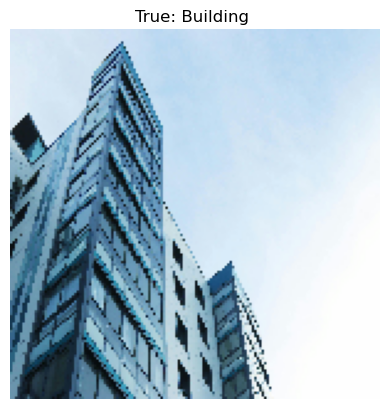

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
CNN Prediction       :  buildings
MobileNet Prediction :  buildings
ResNet50 Prediction  :  buildings


In [65]:
target_class="Building"

# Display the image
plt.imshow(img)
plt.axis('off')
plt.title(f"True: {target_class} ")
plt.show()


# Make prediction using CNN
prediction = model.predict(img_array)
cnn_predicted_class = class_names[np.argmax(prediction)]

# Make prediction using CNN
prediction = model_mobnet.predict(img_array)
mob_predicted_class = class_names[np.argmax(prediction)]

# Make prediction using CNN
prediction = model_rsnet.predict(img_array)
rs_predicted_class = class_names[np.argmax(prediction)]

print("CNN Prediction       : ", cnn_predicted_class)
print("MobileNet Prediction : ", mob_predicted_class)
print("ResNet50 Prediction  : ", rs_predicted_class)





In [66]:
data = {
    "Model": ["CNN", "MobileNetV2", "ResNet50"],
    "Precision": [cnn_pres_scr, mobnet_pres_scr, resnet_pres_scr],
    "Recall": [cnn_recl_scr, mobnet_recl_scr, resnet_recl_scr],
    "F1 Score": [cnn_f1_scr, mobnet_f1_scr, resnet_f1_scr]
}

df = pd.DataFrame(data)

# Print the table
print(df.to_string(index=False))

      Model  Precision   Recall  F1 Score
        CNN   0.843709 0.836496  0.833669
MobileNetV2   0.898643 0.898798  0.898172
   ResNet50   0.596536 0.573656  0.550543


------

#### Summary & Conclusion: ####
The evaluation metrics clearly demonstrate varying performance across the three models:

**MobileNetV2** outperformed the other models across all metrics, achieving the highest Precision (0.8986), Recall (0.8988), and F1 Score (0.8982). This indicates excellent overall classification performance and consistency.

**CNN** delivered moderate results, with a Precision of 0.8437, Recall of 0.8365, and F1 Score of 0.8337. While not as strong as MobileNetV2, its performance is still respectable and may offer advantages in simplicity or training time.

**ResNet50** underperformed significantly with Precision (0.5965), Recall (0.5737), and F1 Score (0.5505). These results suggest challenges in either model fitting, overfitting, or data compatibility.

#### Conclusion: ####
**MobileNetV2** is the most effective model for scene classification in this evaluation, offering both accuracy and balance across metrics. CNN serves as a solid baseline, while ResNet50 may require further tuning or reconsideration for this specific task.

In [75]:
!pip install pandoc

Defaulting to user installation because normal site-packages is not writeable
